In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Load datasets
occupancy = pd.read_csv("occupancy.csv")
price = pd.read_csv("price.csv")
stations = pd.read_csv("stations.csv")
time = pd.read_csv("time.csv")
volume = pd.read_csv("volume.csv")
adj = pd.read_csv("adj.csv")
distance = pd.read_csv("distance.csv")
duration = pd.read_csv("duration.csv")
information = pd.read_csv("information.csv")

# ACN charging session data
acn_sessions = pd.read_excel("acndata_sessions.json.xlsx")

print("Loaded successfully!")

Loaded successfully!


In [6]:
print(occupancy.head())
print(price.head())
print(acn_sessions.head())

   timestamp  102  105  107  108  109  110  111  115  123  ...  1160  1162  \
0          1   12   16   24   15    6    8   24    1    2  ...     0    12   
1          2   12   16   24   15    6    8   24    1    2  ...     0    12   
2          3   12   16   24   15    6    8   24    1    2  ...     0    12   
3          4   12   16   24   15    6    8   24    1    2  ...     0    12   
4          5   12   16   24   15    6    8   24    1    2  ...     0    12   

   1163  1164  1166  1167  1168  1170  1172  1173  
0     1    38    26   162    10     1     8    15  
1     1    38    26   162    10     1     8    15  
2     1    38    26   164    10     1     8    15  
3     1    38    26   166    10     1     8    15  
4     1    38    26   168    10     1     8    15  

[5 rows x 248 columns]
   timestamp    102       105       107   108    109    110       111   115  \
0          1  0.924  1.124167  0.926364  0.99  1.004  1.015  1.111818  1.15   
1          2  0.924  1.124167  0.9263

In [7]:
files = {
    "occupancy": occupancy,
    "price": price,
    "stations": stations,
    "time": time,
    "volume": volume,
    "adj": adj,
    "distance": distance,
    "duration": duration,
    "information": information,
    "acn_sessions": acn_sessions
}

for name, df in files.items():
    print("\n" + "="*60)
    print(name.upper())
    print(df.columns.tolist())
    print(df.shape)


OCCUPANCY
['timestamp', '102', '105', '107', '108', '109', '110', '111', '115', '123', '124', '202', '204', '205', '206', '208', '215', '216', '217', '223', '224', '225', '226', '227', '235', '307', '309', '320', '322', '323', '324', '325', '326', '328', '329', '330', '331', '332', '333', '335', '340', '343', '346', '347', '348', '406', '408', '501', '502', '506', '512', '513', '519', '520', '522', '525', '526', '527', '529', '552', '570', '576', '577', '580', '584', '585', '587', '588', '589', '594', '595', '596', '598', '627', '628', '630', '631', '632', '633', '636', '638', '643', '644', '655', '656', '681', '682', '686', '690', '691', '693', '698', '699', '700', '701', '702', '703', '704', '705', '706', '708', '709', '710', '711', '712', '715', '716', '719', '724', '728', '729', '732', '733', '735', '737', '739', '741', '744', '745', '746', '751', '771', '773', '775', '781', '783', '784', '790', '795', '799', '802', '804', '831', '832', '835', '842', '848', '849', '851', '852', '8

In [9]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")

print("Libraries Loaded")

Libraries Loaded


In [10]:
time["datetime"] = pd.to_datetime(
    time[["year", "month", "day", "hour", "minute", "second"]]
)

time.head()

,month,day,year,hour,minute,second,datetime
0,6,19,2022,0,0,0,2022-06-19 00:00:00
1,6,19,2022,0,5,0,2022-06-19 00:05:00
2,6,19,2022,0,10,0,2022-06-19 00:10:00
3,6,19,2022,0,15,0,2022-06-19 00:15:00
4,6,19,2022,0,20,0,2022-06-19 00:20:00


In [11]:
occupancy["datetime"] = time["datetime"]
volume["datetime"] = time["datetime"]
duration["datetime"] = time["datetime"]
price["datetime"] = time["datetime"]

In [12]:
def melt_station_data(df, value_name):
    
    df_long = df.melt(
        id_vars=["datetime"],
        var_name="station_id",
        value_name=value_name
    )
    
    return df_long


occ_long = melt_station_data(
    occupancy,
    "occupancy"
)

vol_long = melt_station_data(
    volume,
    "volume"
)

dur_long = melt_station_data(
    duration,
    "duration"
)

price_long = melt_station_data(
    price,
    "price"
)

print("Converted successfully")

Converted successfully


In [13]:
urban_df = (
    occ_long
    .merge(vol_long,
           on=["datetime","station_id"])
    .merge(dur_long,
           on=["datetime","station_id"])
    .merge(price_long,
           on=["datetime","station_id"])
)

urban_df.head()


,datetime,station_id,occupancy,volume,duration,price
0,2022-06-19 00:00:00,timestamp,1,1.0,1.0,1.0
1,2022-06-19 00:05:00,timestamp,2,2.0,2.0,2.0
2,2022-06-19 00:10:00,timestamp,3,3.0,3.0,3.0
3,2022-06-19 00:15:00,timestamp,4,4.0,4.0,4.0
4,2022-06-19 00:20:00,timestamp,5,5.0,5.0,5.0


In [14]:
stations["station_id"] = (
    stations["station_id"]
    .astype(str)
)

urban_df["station_id"] = (
    urban_df["station_id"]
    .astype(str)
)

urban_df = urban_df.merge(
    stations,
    on="station_id",
    how="left"
)

urban_df.head()

,datetime,station_id,occupancy,volume,duration,price,latitude,longitude,fast,slow,count
0,2022-06-19 00:00:00,timestamp,1,1.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN
1,2022-06-19 00:05:00,timestamp,2,2.0,2.0,2.0,NaN,NaN,NaN,NaN,NaN
2,2022-06-19 00:10:00,timestamp,3,3.0,3.0,3.0,NaN,NaN,NaN,NaN,NaN
3,2022-06-19 00:15:00,timestamp,4,4.0,4.0,4.0,NaN,NaN,NaN,NaN,NaN
4,2022-06-19 00:20:00,timestamp,5,5.0,5.0,5.0,NaN,NaN,NaN,NaN,NaN


In [15]:
urban_df["hour"] = (
    urban_df["datetime"]
    .dt.hour
)

urban_df["dayofweek"] = (
    urban_df["datetime"]
    .dt.dayofweek
)

urban_df["is_weekend"] = (
    urban_df["dayofweek"] >= 5
).astype(int)

# Utilization Rate
urban_df["utilization_rate"] = (
    urban_df["duration"] / 5
)

urban_df["utilization_rate"] = (
    urban_df["utilization_rate"]
    .clip(0,1)
)

# Congestion proxy
urban_df["congestion"] = (
    urban_df["occupancy"] > 0.8
).astype(int)

# Queue proxy
urban_df["queue_proxy"] = (
    urban_df["occupancy"]
    * urban_df["count"]
)

urban_df.head()

,datetime,station_id,occupancy,volume,duration,price,latitude,longitude,fast,slow,count,hour,dayofweek,is_weekend,utilization_rate,congestion,queue_proxy
0,2022-06-19 00:00:00,timestamp,1,1.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,0,6,1,0.2,1,NaN
1,2022-06-19 00:05:00,timestamp,2,2.0,2.0,2.0,NaN,NaN,NaN,NaN,NaN,0,6,1,0.4,1,NaN
2,2022-06-19 00:10:00,timestamp,3,3.0,3.0,3.0,NaN,NaN,NaN,NaN,NaN,0,6,1,0.6,1,NaN
3,2022-06-19 00:15:00,timestamp,4,4.0,4.0,4.0,NaN,NaN,NaN,NaN,NaN,0,6,1,0.8,1,NaN
4,2022-06-19 00:20:00,timestamp,5,5.0,5.0,5.0,NaN,NaN,NaN,NaN,NaN,0,6,1,1.0,1,NaN


In [16]:
print(urban_df.isnull().sum())

missing_percentage = (
    urban_df.isnull()
    .mean()
    * 100
)

missing_percentage.sort_values(
    ascending=False
)

datetime               0
station_id             0
occupancy              0
volume                 0
duration               0
price                  0
latitude            8640
longitude           8640
fast                8640
slow                8640
count               8640
hour                   0
dayofweek              0
is_weekend             0
utilization_rate       0
congestion             0
queue_proxy         8640
dtype: int64


longitude           0.403226
count               0.403226
fast                0.403226
latitude            0.403226
slow                0.403226
queue_proxy         0.403226
datetime            0.000000
duration            0.000000
station_id          0.000000
price               0.000000
occupancy           0.000000
volume              0.000000
hour                0.000000
dayofweek           0.000000
is_weekend          0.000000
utilization_rate    0.000000
congestion          0.000000
dtype: float64

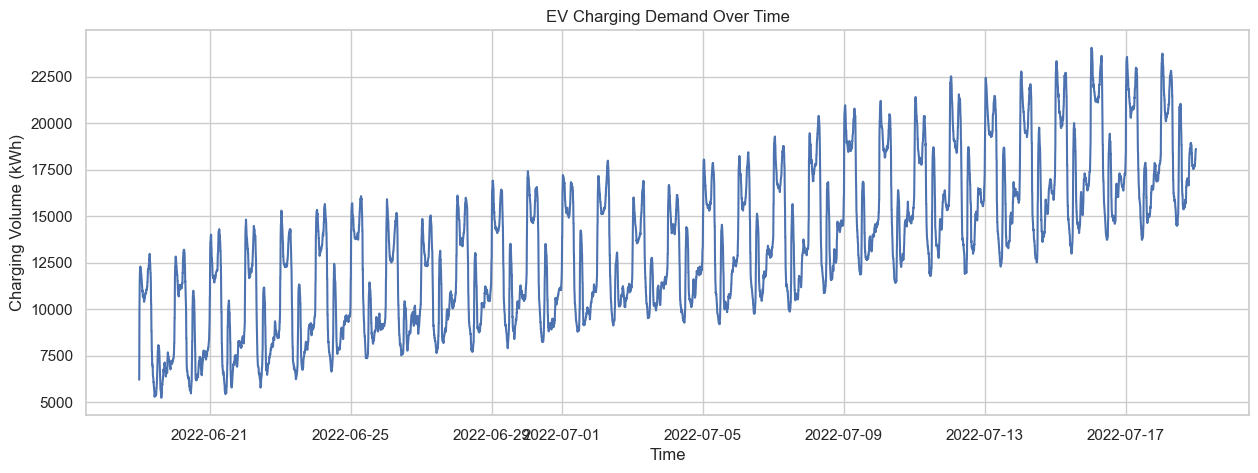

In [17]:
hourly_demand = (
    urban_df
    .groupby("datetime")["volume"]
    .sum()
)

plt.figure(figsize=(15,5))

plt.plot(hourly_demand)

plt.title("EV Charging Demand Over Time")
plt.xlabel("Time")
plt.ylabel("Charging Volume (kWh)")

plt.show()

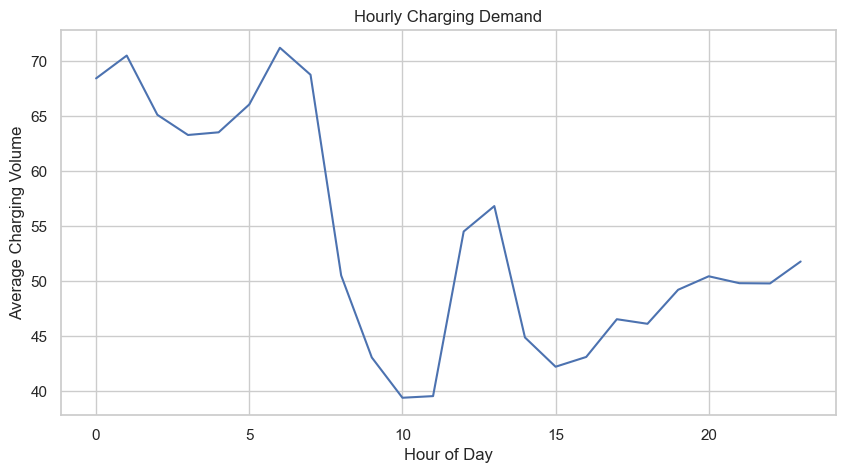

In [18]:
hourly_pattern = (
    urban_df
    .groupby("hour")["volume"]
    .mean()
)

plt.figure(figsize=(10,5))

sns.lineplot(
    x=hourly_pattern.index,
    y=hourly_pattern.values
)

plt.title("Hourly Charging Demand")
plt.xlabel("Hour of Day")
plt.ylabel("Average Charging Volume")

plt.show()

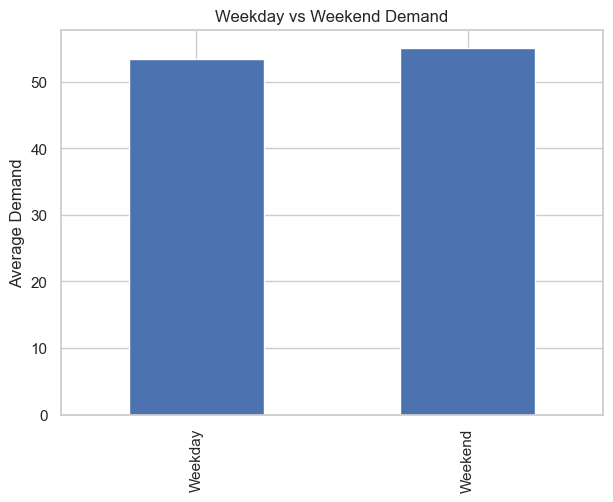

In [19]:
weekday_pattern = (
    urban_df
    .groupby("is_weekend")["volume"]
    .mean()
)

weekday_pattern.index = [
    "Weekday",
    "Weekend"
]

weekday_pattern.plot(
    kind="bar",
    figsize=(7,5)
)

plt.title("Weekday vs Weekend Demand")
plt.ylabel("Average Demand")

plt.show()

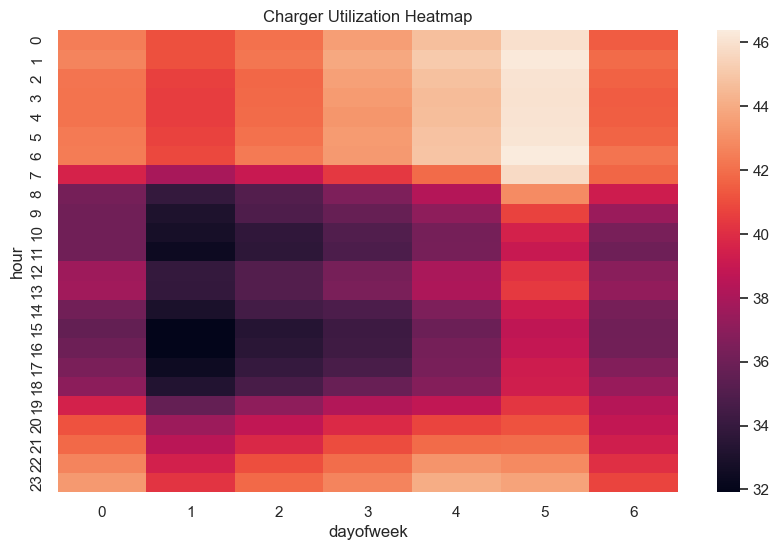

In [20]:
heatmap_data = (
    urban_df
    .pivot_table(
        values="occupancy",
        index="hour",
        columns="dayofweek",
        aggfunc="mean"
    )
)

plt.figure(figsize=(10,6))

sns.heatmap(
    heatmap_data,
    annot=False
)

plt.title(
    "Charger Utilization Heatmap"
)

plt.show()

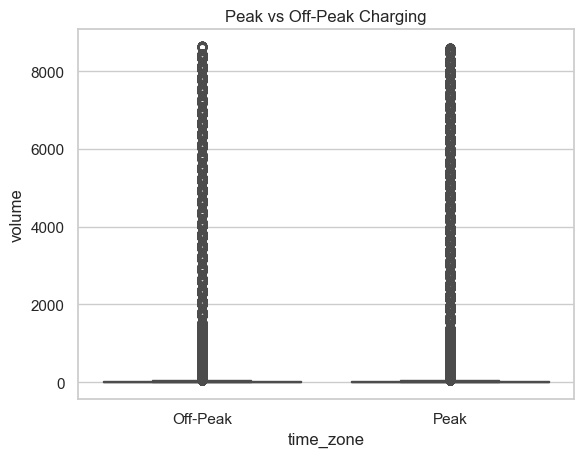

In [21]:
urban_df["time_zone"] = np.where(
    urban_df["hour"].between(8,20),
    "Peak",
    "Off-Peak"
)

sns.boxplot(
    data=urban_df,
    x="time_zone",
    y="volume"
)

plt.title(
    "Peak vs Off-Peak Charging"
)

plt.show()

In [26]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

urban_df["volume_scaled"] = scaler.fit_transform(
    urban_df[["volume"]]
)

In [27]:
urban_df["hour"] = (
    urban_df["datetime"]
    .dt.hour
)

urban_df["dayofweek"] = (
    urban_df["datetime"]
    .dt.dayofweek
)

urban_df["is_weekend"] = (
    urban_df["dayofweek"] >= 5
).astype(int)

# Charger Utilization
urban_df["charger_utilization_rate"] = (
    urban_df["duration"] / 5
).clip(0, 1)

# Occupancy Density
urban_df["occupancy_density"] = (
    urban_df["occupancy"]
)

# Queue Proxy
urban_df["queue_proxy"] = (
    urban_df["occupancy"]
    * urban_df["duration"]
)

# Congestion probability
urban_df["congestion_probability"] = np.where(
    urban_df[
        "charger_utilization_rate"
    ] > 0.8,
    1,
    0
)

urban_df.dropna(inplace=True)

In [28]:
features = [

    "occupancy",
    "duration",
    "price",

    "hour",
    "dayofweek",
    "is_weekend",

    "charger_utilization_rate",
    "occupancy_density",
    "queue_proxy"
]

target = "volume_scaled"

In [29]:
from sklearn.model_selection import train_test_split

X = urban_df[features]
y = urban_df[target]

X_train, X_test, y_train, y_test = (
    train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42
    )
)

In [30]:
!pip install xgboost lightgbm catboost

   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.5/100.2 MB 985.5 kB/s eta 0:01:42
   ---------------------------------------- 0.8/100.2 MB 907.1 kB/s eta 0:01:50
   ---------------------------------------- 0.8/100.2 MB 907.1 kB/s eta 0:01:50
    --------------------------------------- 1.3/100.2 MB 1.1 MB/s eta 0:01:30
    --------------------------------------- 1.8/100.2 MB 1.3 MB/s eta 0:01:16
    --------------------------------------- 2.4/100.2 MB 1.5 MB/s eta 0:01:07
   - -------------------------------------- 2.9/100.2 MB 1.6 MB/s eta 0:01:00
   - -------------------------------------- 3.7/100.2 MB 1.8 MB/s eta 0:00:54
   - ----------

In [31]:
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.ensemble import RandomForestRegressor

models = {

    "XGBoost": XGBRegressor(
        n_estimators=150,
        learning_rate=0.05,
        max_depth=6,
        random_state=42
    ),

    "LightGBM": LGBMRegressor(
        n_estimators=150,
        learning_rate=0.05,
        max_depth=6,
        random_state=42
    ),

    "CatBoost": CatBoostRegressor(
        iterations=150,
        learning_rate=0.05,
        depth=6,
        verbose=0,
        random_state=42
    ),

    "Random Forest": RandomForestRegressor(
        n_estimators=100,
        max_depth=10,
        random_state=42
    )
}

results = []

for name, model in models.items():

    model.fit(
        X_train,
        y_train
    )

    preds = model.predict(
        X_test
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            preds
        )
    )

    mae = mean_absolute_error(
        y_test,
        preds
    )

    r2 = r2_score(
        y_test,
        preds
    )

    results.append([
        name,
        rmse,
        mae,
        r2
    ])

results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "RMSE",
        "MAE",
        "R2"
    ]
)

results_df

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.033373 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1459
[LightGBM] [Info] Number of data points in the train set: 1707264, number of used features: 9
[LightGBM] [Info] Start training from score 0.004249


,Model,RMSE,MAE,R2
0,XGBoost,0.004902,0.002202,0.826373
1,LightGBM,0.005052,0.002306,0.815639
2,CatBoost,0.006306,0.002930,0.712733
3,Random Forest,0.004917,0.001981,0.825328


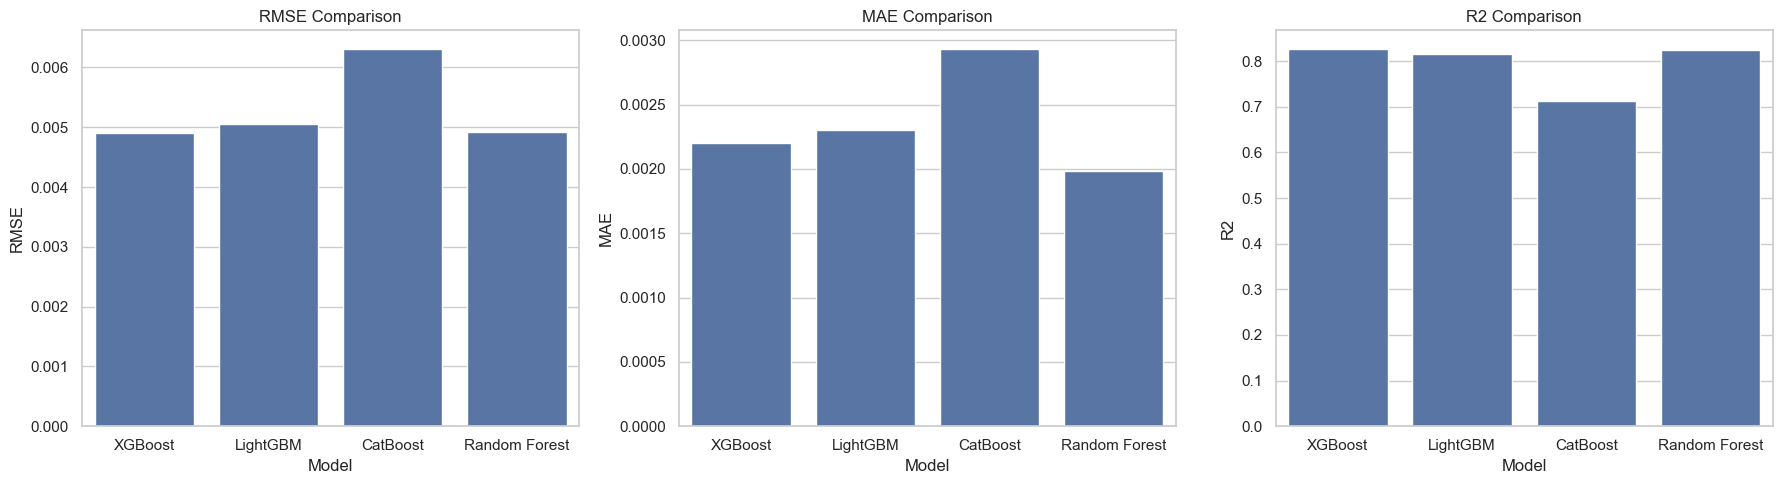

In [32]:
fig, ax = plt.subplots(
    1,
    3,
    figsize=(18,5)
)

sns.barplot(
    data=results_df,
    x="Model",
    y="RMSE",
    ax=ax[0]
)

ax[0].set_title(
    "RMSE Comparison"
)

sns.barplot(
    data=results_df,
    x="Model",
    y="MAE",
    ax=ax[1]
)

ax[1].set_title(
    "MAE Comparison"
)

sns.barplot(
    data=results_df,
    x="Model",
    y="R2",
    ax=ax[2]
)

ax[2].set_title(
    "R2 Comparison"
)

plt.tight_layout()
plt.show()